<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Ephemeride_de_magnitude_V_de_delta_Cephei.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2026-09-01 21:00 UTC  ->  JD 2461285.37500  phi=0.868  V=4.019  (+/- ~0.097 fidelite template)

  JD          phase     V
  2461285.3750   0.868   4.019
  2461286.3750   0.054   3.436
  2461287.3750   0.240   3.776
  2461288.3750   0.427   3.987
  2461289.3750   0.613   4.143
  2461290.3750   0.799   4.245
  2461291.3750   0.986   3.508
  2461292.3750   0.172   3.660
  2461293.3750   0.358   3.899
  2461294.3750   0.545   4.094
  2461295.3750   0.731   4.280


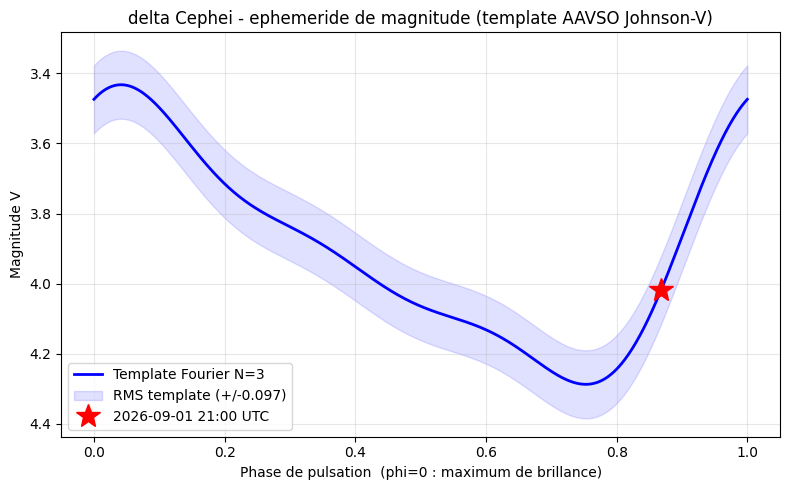

In [3]:
# =====================================================================
#  Ephemeride de magnitude V de delta Cephei
#  Template Fourier N=3  -  Elahi & Gull (2026), arXiv:2606.29543
#  Donnees sources : AAVSO International Database (Johnson-V)
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# ---------------------------------------------------------------------
#  1. Elements du template (Table 3 de l'article, valeurs exactes)
# ---------------------------------------------------------------------
A0 = 3.903085                                     # magnitude moyenne
ck = np.array([-0.242286, -0.133974, -0.052745])  # coefficients cosinus
sk = np.array([-0.243384, -0.049481,  0.006366])  # coefficients sinus

P_obs = 5.366531          # periode de pulsation adoptee (jours)
T0     = 2460851.395800   # epoque de MAXIMUM de brillance (JD)
                          #  -> phi = 0 correspond a l'eclat maximal (V mini)

# Le T0 et la periode viennent d'un jeu AAVSO couvrant environ un an autour de mi-2026 (P = 5,366531 j, T0 = JD 2460851,3958).
# Delta Cep a une derive de periode lente et documentee ; sur quelques mois l'erreur de phase reste negligeable,
# mais dans un ou deux ans, le maximum aura glisse de quelques centiemes de phase.
# Rafraichir alors T0 depuis la courbe AAVSO recente.

# ---------------------------------------------------------------------
#  2. Conversions de date
# ---------------------------------------------------------------------
def datetime_to_jd(dt):
    """Datetime UTC -> Jour Julien (JD). Attention : JD, pas JD heliocentrique."""
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    # algorithme standard (Fliegel-Van Flandern)
    a = (14 - dt.month) // 12
    y = dt.year + 4800 - a
    m = dt.month + 12 * a - 3
    jdn = (dt.day + (153 * m + 2) // 5 + 365 * y + y // 4
           - y // 100 + y // 400 - 32045)
    frac = (dt.hour - 12) / 24 + dt.minute / 1440 + dt.second / 86400
    return jdn + frac

# ---------------------------------------------------------------------
#  3. Le modele : magnitude et phase
# ---------------------------------------------------------------------
def phase(jd):
    jd = np.asarray(jd, float)
    return ((jd - T0) / P_obs) % 1.0

def Vmag(jd):
    """Magnitude V predite par le template Fourier N=3 a une (ou des) date(s) JD."""
    jd = np.atleast_1d(np.asarray(jd, float))
    phi = phase(jd)
    V = np.full_like(phi, A0)
    for k in (1, 2, 3):
        V += ck[k-1] * np.cos(2*np.pi*k*phi) + sk[k-1] * np.sin(2*np.pi*k*phi)
    return V if V.size > 1 else float(V[0])

# Incertitude indicative : dispersion residuelle du template sur donnees AAVSO
# (RMS ~0.097 mag, heterogene multi-observateurs).
# C'est l'ordre de grandeur de fidelite du modele moyen.
RMS_TEMPLATE = 0.097

# ---------------------------------------------------------------------
#  4. Ephemeride sur une plage de dates
# ---------------------------------------------------------------------
def ephemeride(jd_start, n_jours, pas_jours=1.0):
    """Retourne (jd, phase, Vmag) echantillonnes sur la plage demandee."""
    jd = np.arange(jd_start, jd_start + n_jours + 1e-9, pas_jours)
    return jd, phase(jd), Vmag(jd)

# =====================================================================
#  UTILISATION
# =====================================================================

# --- Date d'interet (UTC) --------------------------------------------
#     Modifie l'annee/mois/jour/heure ci-dessous :
dt = datetime(2026, 9, 1, 21, 0, 0, tzinfo=timezone.utc)
jd = datetime_to_jd(dt)
print(f"{dt:%Y-%m-%d %H:%M UTC}  ->  JD {jd:.5f}  phi={phase(jd):.3f}  V={Vmag(jd):.3f}"
      f"  (+/- ~{RMS_TEMPLATE:.3f} fidelite template)")
print()

# --- Ephemeride journaliere sur les 10 jours a partir de cette date --
jd_grid_e, phi_e, V_e = ephemeride(jd, n_jours=10, pas_jours=1.0)
print("  JD          phase     V")
for j, p, v in zip(jd_grid_e, phi_e, V_e):
    print(f"  {j:.4f}   {p:5.3f}   {v:5.3f}")

# ---------------------------------------------------------------------
#  5. Courbe : template complet + position a la date saisie
# ---------------------------------------------------------------------
phi_grid = np.linspace(0, 1, 500)
jd_grid  = T0 + phi_grid * P_obs
V_grid   = Vmag(jd_grid)

plt.figure(figsize=(8, 5))
plt.plot(phi_grid, V_grid, 'b-', lw=2, label='Template Fourier N=3')
plt.fill_between(phi_grid, V_grid - RMS_TEMPLATE, V_grid + RMS_TEMPLATE,
                 color='blue', alpha=0.12, label=f'RMS template (+/-{RMS_TEMPLATE})')
plt.plot(phase(jd), Vmag(jd), 'r*', ms=18,
         label=f'{dt:%Y-%m-%d %H:%M UTC}')
plt.gca().invert_yaxis()           # magnitude : brillant en haut
plt.xlabel('Phase de pulsation  (phi=0 : maximum de brillance)')
plt.ylabel('Magnitude V')
plt.title('delta Cephei - ephemeride de magnitude (template AAVSO Johnson-V)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()